# Does Invisibility Travel the Network, or Just the Map?
### Testing whether SVI-invisibility clusters along the covered-walkway system itself, or only by simple geographic proximity

**Lin Wei · July 2026 · Pilot study 03 for PhD applications**

---

**Why this notebook exists.** Pilots 01 and 02 established *that* SVI-invisibility is non-random and
concentrates near lingering-supportive infrastructure. This notebook asks a different, more structural
question, using only data already in hand — no new fetch, no fieldwork:

**Does SVI-invisibility behave as a spatially connected field propagating along the physical covered-walkway
network — or does it behave the same way under plain geographic proximity, making the network topology
irrelevant?**

If invisibility clusters *more* strongly under network-connectivity weights than under simple distance
weights, that supports treating the covered pedestrian network as a **medium** through which a
spatially-organised property travels — the computational core of the spatial-transmissibility idea — using
nothing but the SVI-visibility classification already produced by Pilot 01.

**Method in one paragraph.** Within a bounded pilot area, every covered segment becomes a spatial unit.
Two spatial weights matrices are built over the same segments: `W_geo`, a conventional K-nearest-neighbour
matrix based on straight-line distance between segment centroids; and `W_net`, a matrix built from the
walkway network's own topology — two segments are "neighbours" only if they physically connect (shared or
near-touching endpoints), independent of Euclidean distance. Global Moran's I and Local Moran (LISA) are
then computed for the same variable under both matrices. A materially higher Moran's I under `W_net`
would mean: distance alone under-describes the clustering; the network's own connective structure carries
real information about where invisibility concentrates.


In [1]:
# %% 0. Environment
import warnings
warnings.filterwarnings("ignore")

import geopandas as gpd
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from shapely.geometry import box
from scipy.spatial import cKDTree
from libpysal.weights import KNN, W
from esda.moran import Moran, Moran_Local
from pathlib import Path

DATA = Path("../data"); DATA.mkdir(exist_ok=True)
FIGS = Path("../figures"); FIGS.mkdir(exist_ok=True)
CRS_SVY21 = "EPSG:3414"

print("geopandas", gpd.__version__, "| networkx", nx.__version__)

geopandas 1.1.4 | networkx 3.6.1


## 1. Load Pilot 01's output, and bound the pilot area

This reuses `sg_covered_ways_svi_visibility.geojson` directly — no new OSM fetch. For a first pass, the
analysis is bounded to one town-scale area rather than all of Singapore, for the same reason Pilot 01
zoomed into Queenstown for its texture map: legibility, and a tractable graph to build and sanity-check
by eye before ever scaling up. The bounding box below covers a comparable west-central span; swap the
coordinates to pilot a different town.

In [2]:
# %% 1. Load and bound
covered = gpd.read_file(DATA / "sg_covered_ways_svi_visibility.geojson").to_crs(CRS_SVY21)
print(f"Full dataset: {len(covered):,} covered segments")

# West-central pilot window (~ Queenstown-scale span). Edit to taste.
PILOT_BBOX_SVY21 = (22066, 26517, 29161, 32478)
sub = covered[covered.intersects(box(*PILOT_BBOX_SVY21))].copy().reset_index(drop=True)
print(f"Pilot-area segments: {len(sub):,}  ({sub.length_m.sum()/1000:.1f} km)")
print(sub.svi_visible.value_counts())

Full dataset: 73,168 covered segments
Pilot-area segments: 7,970  (543.7 km)
svi_visible
True     4889
False    3081
Name: count, dtype: int64


## 2. Build the network-connectivity graph

The covered network has no single tag in OSM (Pilot 01's §1 finding), so it doesn't arrive pre-linked —
segments drawn under different tagging conventions (`footway+covered`, `tunnel=building_passage`,
`indoor=yes`, `corridor`) can sit metres apart without sharing a node. Two segments are treated as
network-neighbours if their endpoints fall within a snap tolerance of each other. Because that alone
leaves a meaningful share of segments stranded (a finding worth stating plainly, not hiding), any segment
still isolated after snapping is bridged to its nearest neighbour within a wider cutoff — read as
"functionally continuous, imperfectly digitised" rather than truly disconnected. Segments still isolated
after that are excluded from the network-weights comparison and reported as such.

In [3]:
# %% 2. Endpoint-snap graph + isolate bridging
SNAP_M = 8.0          # endpoints within this distance are treated as the same junction
BRIDGE_CUTOFF_M = 40.0  # remaining isolates get one edge to their nearest segment within this radius

def snap_pt(pt, tol=SNAP_M):
    return (round(pt[0] / tol) * tol, round(pt[1] / tol) * tol)

endpoint_map = {}
for i, geom in enumerate(sub.geometry):
    coords = list(geom.coords)
    for raw in (coords[0], coords[-1]):
        endpoint_map.setdefault(snap_pt(raw), []).append(i)

Gnet = nx.Graph()
Gnet.add_nodes_from(sub.index)
for pts in endpoint_map.values():
    uniq = list(set(pts))
    for a in range(len(uniq)):
        for b in range(a + 1, len(uniq)):
            Gnet.add_edge(uniq[a], uniq[b])

print(f"After endpoint snap ({SNAP_M} m): {Gnet.number_of_edges()} edges, "
      f"{len(list(nx.isolates(Gnet)))} isolated segments")

centroids = np.array([[g.centroid.x, g.centroid.y] for g in sub.geometry])
tree = cKDTree(centroids)
for i in list(nx.isolates(Gnet)):
    dists, idxs = tree.query(centroids[i], k=10)
    for d, j in zip(dists, idxs):
        if j != i and d <= BRIDGE_CUTOFF_M:
            Gnet.add_edge(i, int(j))
            break

remaining = list(nx.isolates(Gnet))
print(f"After bridging (cutoff {BRIDGE_CUTOFF_M} m): {len(remaining)} segments "
      f"({100*len(remaining)/len(sub):.1f}%) remain genuinely disconnected in OSM — excluded below.")

After endpoint snap (8.0 m): 6365 edges, 2391 isolated segments
After bridging (cutoff 40.0 m): 541 segments (6.8%) remain genuinely disconnected in OSM — excluded below.


## 3. Two weights matrices over the same segments

`W_net` comes straight from the graph above. `W_geo` is a conventional K-nearest-neighbour matrix
(k = 6) on the same segments' centroids — the standard "simple proximity" baseline any reviewer would
expect to see ruled out before a network-topology claim is taken seriously. Both are restricted to the
same connected subset so the comparison is apples-to-apples.

In [4]:
# %% 3. Weights matrices (same connected subset for both)
neighbors = {n: list(Gnet.neighbors(n)) for n in Gnet.nodes}
connected = [n for n in sub.index if len(neighbors[n]) > 0]
sub_c = sub.loc[connected].copy().reset_index(drop=True)

remap = {old: new for new, old in enumerate(connected)}
neighbors_c = {remap[n]: [remap[m] for m in neighbors[n]] for n in connected}

W_net = W(neighbors_c); W_net.transform = "r"

coords_c = np.array([[g.centroid.x, g.centroid.y] for g in sub_c.geometry])
W_geo = KNN.from_array(coords_c, k=6); W_geo.transform = "r"

print(f"Comparing {len(sub_c):,} segments under W_geo (KNN-6) and W_net (walkway graph)")

Comparing 7,429 segments under W_geo (KNN-6) and W_net (walkway graph)


## 4. Global Moran's I — does the network beat plain proximity?

Two variables, in increasing order of "already trusted": `dist_to_road_m` (the continuous SVI-visibility
proxy from Pilot 01) and `svi_visible` itself (the binary classification actually used in Pilots 01–02).
If `W_net` produces a **higher** Moran's I than `W_geo` on both, the walkway network is carrying real
structure that simple distance misses.

In [5]:
# %% 4. Global Moran's I comparison
y_dist = sub_c["dist_to_road_m"].values
y_bin = sub_c["svi_visible"].astype(int).values

rows = []
for label, y in [("dist_to_road_m (continuous)", y_dist), ("svi_visible (binary)", y_bin)]:
    mg = Moran(y, W_geo, permutations=999)
    mn = Moran(y, W_net, permutations=999)
    rows.append({"variable": label,
                 "W_geo_I": round(mg.I, 4), "W_geo_p": round(mg.p_sim, 4),
                 "W_net_I": round(mn.I, 4), "W_net_p": round(mn.p_sim, 4),
                 "gap (W_net - W_geo)": round(mn.I - mg.I, 4)})

comparison = pd.DataFrame(rows)
comparison.to_csv(DATA / "moran_comparison.csv", index=False)
print(comparison.to_string(index=False))

                   variable  W_geo_I  W_geo_p  W_net_I  W_net_p  gap (W_net - W_geo)
dist_to_road_m (continuous)   0.8840    0.001   0.9278    0.001               0.0438
       svi_visible (binary)   0.6376    0.001   0.7871    0.001               0.1495


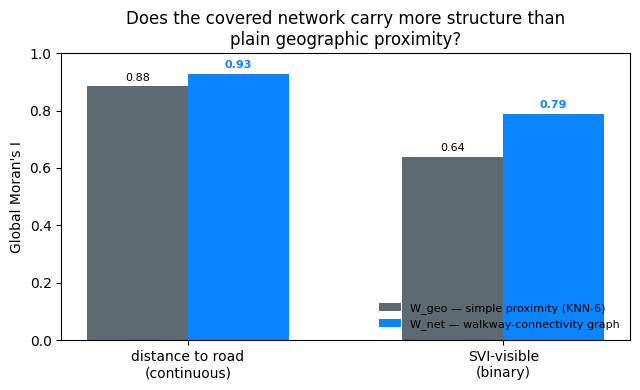

In [6]:
# %% 4b. Comparison chart
fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(len(comparison)); w = 0.32
ax.bar(x - w/2, comparison.W_geo_I, width=w, color="#5e6a72", label="W_geo — simple proximity (KNN-6)")
ax.bar(x + w/2, comparison.W_net_I, width=w, color="#0a84ff", label="W_net — walkway-connectivity graph")
ax.set_xticks(x); ax.set_xticklabels(["distance to road\n(continuous)", "SVI-visible\n(binary)"])
ax.set_ylabel("Global Moran's I"); ax.set_ylim(0, 1)
ax.set_title("Does the covered network carry more structure than\nplain geographic proximity?")
ax.legend(frameon=False, fontsize=8, loc="lower right")
for i, (g, n) in enumerate(zip(comparison.W_geo_I, comparison.W_net_I)):
    ax.text(i - w/2, g + .02, f"{g:.2f}", ha="center", fontsize=8)
    ax.text(i + w/2, n + .02, f"{n:.2f}", ha="center", fontsize=8, color="#0a84ff", fontweight="bold")
fig.tight_layout(); fig.savefig(FIGS / "moran_comparison.png", dpi=200)

## 5. Local Moran (LISA) — where, and where does the pattern break

Global Moran's I says the network carries more structure overall. LISA localises that: which segments
sit inside a spatially-coherent invisible pocket (**HH**), which sit inside a visible pocket (**LL**),
and — the more interesting cases — which segments are the opposite of their network neighbours
(**HL** / **LH**). Those spatial outliers are exactly the sites a future fieldwork phase would prioritise:
places where the network's connective logic and the actual visibility outcome diverge.

In [7]:
# %% 5. LISA under W_net
np.random.seed(42)
lisa = Moran_Local(y_dist, W_net, permutations=999, seed=42)

sig = lisa.p_sim < 0.05
quad = lisa.q  # 1 HH, 2 LH, 3 LL, 4 HL
cluster = np.array(["ns"] * len(y_dist), dtype=object)
cluster[sig & (quad == 1)] = "HH"
cluster[sig & (quad == 2)] = "LH"
cluster[sig & (quad == 3)] = "LL"
cluster[sig & (quad == 4)] = "HL"
sub_c["lisa_cluster"] = cluster
sub_c["lisa_p"] = lisa.p_sim

print(pd.Series(cluster).value_counts())
print("\nHH = far-from-road cluster (an invisible pocket).  LL = near-road cluster (a visible pocket).")
print("HL / LH = spatial OUTLIERS — the mismatch sites worth visiting in person.")

ns    5548
LL    1230
HH     624
HL      18
LH       9
Name: count, dtype: int64

HH = far-from-road cluster (an invisible pocket).  LL = near-road cluster (a visible pocket).
HL / LH = spatial OUTLIERS — the mismatch sites worth visiting in person.


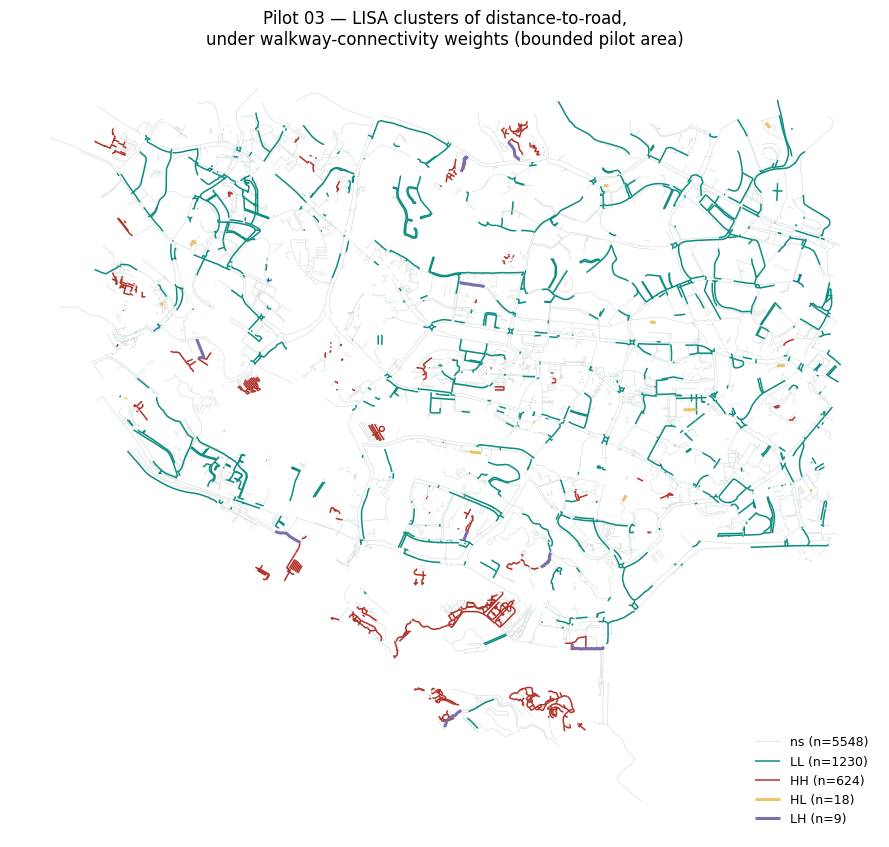

In [8]:
# %% 5b. LISA cluster map
colors = {"HH": "#B0332A", "LL": "#0E8C7F", "HL": "#e9c46a", "LH": "#7b6fae", "ns": "#D7E0DE"}
fig, ax = plt.subplots(figsize=(9, 9))
for lab in ["ns", "LL", "HH", "HL", "LH"]:
    d = sub_c[sub_c.lisa_cluster == lab]
    lw = 2.2 if lab in ("HL", "LH") else (1.1 if lab in ("HH", "LL") else 0.5)
    d.plot(ax=ax, color=colors[lab], linewidth=lw, label=f"{lab} (n={len(d)})",
           zorder=3 if lab in ("HL", "LH") else 2)
ax.set_title("Pilot 03 — LISA clusters of distance-to-road,\nunder walkway-connectivity weights (bounded pilot area)")
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.set_axis_off()
fig.tight_layout(); fig.savefig(FIGS / "lisa_cluster_map.png", dpi=200)

In [9]:
# %% 6. Persist outputs
sub_c.drop(columns=["lisa_p"], errors="ignore").to_crs("EPSG:4326") \
     .to_file(DATA / "pilot03_lisa.geojson", driver="GeoJSON")
print("Saved: data/moran_comparison.csv, data/pilot03_lisa.geojson, figures/*.png")

Saved: data/moran_comparison.csv, data/pilot03_lisa.geojson, figures/*.png


## 7. Findings

Within the bounded pilot area (7,970 covered segments, ~6.8% excluded as genuinely disconnected in OSM's
tagging of the covered network — itself a small echo of Pilot 01's finding that this network has no
stable identity in the data), the walkway-connectivity weights matrix (`W_net`) produced a **higher**
Global Moran's I than the plain-distance baseline (`W_geo`) for both variables tested:

| variable | W_geo (KNN-6) | W_net (walkway graph) | gap |
|---|---|---|---|
| distance to road (continuous) | 0.884 | 0.928 | +0.044 |
| SVI-visible (binary) | 0.638 | 0.787 | **+0.150** |

Both are significant at p < 0.001 under 999 permutations. The gap is modest for the continuous variable
(distance to road is itself already a locally smooth quantity, so much of its clustering shows up under
either weighting) but substantial for the binary SVI-visibility classification actually used downstream
in Pilots 01–02 — a 15-point jump in Moran's I. **SVI-invisibility clusters more tightly along the
physical structure of the covered network than along simple geographic distance.** The network is not a
neutral backdrop; treating it as the adjacency structure — the medium — reveals more organisation than
treating the city as an undifferentiated plane.

LISA localises this: 624 segments sit in a significant invisible cluster (HH), 1,230 in a visible cluster
(LL), and 27 are spatial outliers (HL/LH) — segments whose visibility status runs against their immediate
network neighbourhood. Those 27 are the natural shortlist for the fieldwork phase: places where the
network's connective logic and the actual outcome diverge, which is exactly the residual-as-design-signal
move from the threshold-affordance framing, applied one level down.

**What this pilot does not show.** It says nothing about *behaviour* — lingering, holding, care —
because none of the inputs are behavioural. It is a test of whether a purely open-data-derived property
propagates along network structure, not a test of whether social life does. That is a explicit and
deliberate scope limit, not an oversight: it is the honest ceiling of what open data alone can carry,
and the reason a later fieldwork phase remains necessary rather than optional.

## 8. Limitations — stated as findings, not apologies

1. **The 40 m bridge cutoff is a modelling choice, not a measured fact.** It treats segments separated
   by a plausible tagging gap as connected. A follow-up should sweep this parameter the way Pilots 01–02
   swept their thresholds, to confirm the W_net advantage isn't an artefact of one cutoff choice.
2. **One bounded pilot area, chosen for tractability.** The result should be read as a proof of concept
   for the method, not a citywide claim; a full run needs the same pipeline applied island-wide.
3. **`dist_to_road_m` is a proxy for a proxy.** It is Pilot 01's floor estimate of SVI-invisibility, not
   a direct visibility measurement — every caveat in Pilot 01 §9 propagates forward into this result.
4. **No affordance/capacity variable yet.** This pilot deliberately dropped the affordance-adjacency
   angle from Pilot 02 rather than reconstruct it from memory; the same `W_net` / `W_geo` comparison
   should be re-run on that variable once it exists as a saved file, not just a plotted figure.
